In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. 데이터 수집 및 초기화:
   - AI Hub 금융 합성 데이터셋(2022년 12월 기준 개인 CB 데이터)을 로드.
   - 연체 발생에 유의미한 영향을 미치는 변수 21개 선정
   - 1) 신용 및 대출 레버리지 지표(한도소진율(신용카드/단기대출),대출 총건수/총약정금액/총기관수): 현재 단기적 유동성 압박 지표, 차주의 부채 부담 수준을 정량화하여 연체 위험성 평가
   - 2) 이용 행태 및 결제 이력(신용카드 일시불/할부 이용금액, 3개월내 카드총이용금액,리볼빙이용카드수,총연체상환금액): 최근 이용 금액을 통한 소비 규모 변화 및 선행 지표 파악, 리볼빙 이용을 통한 현금 흐름 위기 신호 탐지, 과거 상환 이력을 통한 미래 연체 가능성 예측
   - 3) 사회경제적 배경: 성별, 연령대, 총자산평가금액, 현거주지평형구간, 3년내 직장/자택주소이력건수: 차주의 안정성 판단 변수, 자산 및 거주지 정보로 경제적 기초 보완 설명
   - 데이터 컬럼명을 분석 및 논문 작성이 용이하도록 한글 명칭으로 변환

In [ ]:
import polars as pl
import pandas as pd

target_columns = [
    'GENDER', 'AGE_BAND',
    'C1M2B4W03', 'C1M2B5W03',
    'C1L120237', 'C1L120049', 'C1L120168',
    'L10210000', 'L10231000', 'L10210800', 'L90210100',
    'D10133000',
    'U81201010', 'AS120G001',
    'AL012G011', 'AL012G005',
    'D10175000',


    'C1L120012',  # 신용카드총한도금액
    'L10220000',  # 대출_총기관수
    'U81301010',  # 거주지_매매가
    'C1Z001373'   # 3개월내 카드총이용금액
]

# rename_dict = {
#     'GENDER': '성별', 'AGE_BAND': '연령대',
#     'C1M2B4W03': '신용카드_일시불이용금액', 'C1M2B5W03': '신용카드_할부이용금액',
#     'C1L120237': '신용카드_한도소진율', 'C1L120049': '단기카드대출_소진율', 'C1L120168': '리볼빙_이용카드수',
#     'L10210000': '대출_총건수', 'L10231000': '대출_총약정금액', 'L10210800': '저축은행_대출건수', 'L90210100': '은행업종_대출건수',
#     'D10133000': '총연체상환금액', 'U81201010': '총자산평가금액_구간', 'AS120G001': '현거주지_평형구간',
#     'AL012G011': '3년내_직장이력건수', 'AL012G005': '3년내_자택주소이력건수',
#     'D10175000': '최장연체일수',


#     'C1L120012': '신용카드_총한도금액',
#     'L10220000': '대출_총기관수',
#     'U81301010': '거주지_매매가',
#     'C1Z001373': '3개월내_카드총이용금액'
# }

rename_dict = {
    'GENDER': 'Gender', 'AGE_BAND': 'Age_Band',
    'C1M2B4W03': 'Card_Lump_Amt', 'C1M2B5W03': 'Card_Install_Amt',
    'C1L120237': 'Card_Limit_Usage', 'C1L120049': 'CA_Usage_Rate', 'C1L120168': 'Revolving_Cards',
    'L10210000': 'Loan_Count', 'L10231000': 'Loan_Amt', 'L10210800': 'Savings_Loan_Cnt', 'L90210100': 'Bank_Loan_Cnt',
    'D10133000': 'Overdue_Repay_Amt', 'U81201010': 'Asset_Value', 'AS120G001': 'House_Size',
    'AL012G011': 'Job_History_3Y', 'AL012G005': 'Addr_History_3Y',
    'D10175000': 'Max_Overdue_Days',
    'C1L120012': 'Card_Total_Limit',
    'L10220000': 'Loan_Inst_Cnt',
    'U81301010': 'Home_Price',
    'C1Z001373': 'Card_Use_3M'
}

file_path = "/content/drive/MyDrive/Colab Notebooks/sample/개인CB/202212_개인CB.csv"

lazy_df = (
    pl.scan_csv(
        file_path,
        encoding='utf8-lossy',
        infer_schema_length=10000
    )
    .select(target_columns)
)

df = lazy_df.collect().to_pandas()
df.rename(columns=rename_dict, inplace=True)

print(f"최종 데이터 크기 (행, 열): {df.shape}")
print("-" * 60)

display(df.head())

최종 데이터 크기 (행, 열): (3129036, 21)
------------------------------------------------------------


,Gender,Age_Band,Card_Lump_Amt,Card_Install_Amt,Card_Limit_Usage,CA_Usage_Rate,Revolving_Cards,Loan_Count,Loan_Amt,Savings_Loan_Cnt,...,Overdue_Repay_Amt,Asset_Value,House_Size,Job_History_3Y,Addr_History_3Y,Max_Overdue_Days,Card_Total_Limit,Loan_Inst_Cnt,Home_Price,Card_Use_3M
0,2,4,7723,1310,17.7,8888888.8,0,0,0,0,...,0,161783,1,1,2,0,NaN,0,166348,12146
1,1,6,-228,0,8888888.8,8888888.8,0,0,12133,0,...,0,545584,3,1,1,0,NaN,0,547192,1405
2,2,3,11194,13407,94.5,21.4,1,5,39582,0,...,0,299446,5,2,4,0,30118.0,6,116185,31515
3,1,5,317,1385,86.6,131.0,1,5,424550,1,...,0,186802,-9,2,1,0,7712.0,3,888968,22953
4,1,5,6906,0,15.9,8888888.8,0,0,0,0,...,0,298431,3,2,1,0,NaN,0,299953,2740


2. 결측치 및 이상치 탑색
   - 금융 데이터 내 특수값(8888888.8: 미보유/결측, -9: 정보 없음 등)을 탐색하여 모델의 편향을 유발할 수 있는 노이즈를 식별.

In [ ]:
# 특수값 확인

print((df == 8888888.8).sum())
print()
print((df == -9).sum())

Gender                     0
Age_Band                   0
Card_Lump_Amt              0
Card_Install_Amt           0
Card_Limit_Usage     1653303
CA_Usage_Rate        2286361
Revolving_Cards            0
Loan_Count                 0
Loan_Amt                   0
Savings_Loan_Cnt           0
Bank_Loan_Cnt              0
Overdue_Repay_Amt          0
Asset_Value                0
House_Size                 0
Job_History_3Y             0
Addr_History_3Y            0
Max_Overdue_Days           0
Card_Total_Limit           0
Loan_Inst_Cnt              0
Home_Price                 0
Card_Use_3M                0
dtype: int64

Gender                     0
Age_Band                   0
Card_Lump_Amt            104
Card_Install_Amt          22
Card_Limit_Usage         438
CA_Usage_Rate              0
Revolving_Cards            0
Loan_Count                 0
Loan_Amt                   0
Savings_Loan_Cnt           0
Bank_Loan_Cnt              0
Overdue_Repay_Amt          0
Asset_Value                0


3. 데이터 전처리(결측치 대치 및 특수 처리):
   - 미보유/정보없음 등 특수값을 NaN으로 통일하여 결측치로 처리.
   - 직장이력/주소이력 등 단순 누락인 경우 0으로 대치하여 데이터 손실 최소화.
   - 현거주지 평형구간 등 특정 카테고리는 데이터의 맥락을 살리기 위해 '정보없음'이라는 별도 범주로 할당.

In [ ]:
# 특수값 NaN 으로 대치

import numpy as np
df = df.replace(8888888.8, np.nan)
df = df.replace(-9, np.nan)

print(df.isnull().sum())
print()
print(f"전체 결측치 비율:\n{(df.isnull().sum() / len(df) * 100).round(2)}")

Gender                     0
Age_Band                   0
Card_Lump_Amt            104
Card_Install_Amt          22
Card_Limit_Usage     1653741
CA_Usage_Rate        2286361
Revolving_Cards            0
Loan_Count                 0
Loan_Amt                   0
Savings_Loan_Cnt           0
Bank_Loan_Cnt              0
Overdue_Repay_Amt          0
Asset_Value                0
House_Size           1771906
Job_History_3Y            30
Addr_History_3Y           33
Max_Overdue_Days           0
Card_Total_Limit     2285621
Loan_Inst_Cnt              0
Home_Price                 0
Card_Use_3M              118
dtype: int64

전체 결측치 비율:
Gender                0.00
Age_Band              0.00
Card_Lump_Amt         0.00
Card_Install_Amt      0.00
Card_Limit_Usage     52.85
CA_Usage_Rate        73.07
Revolving_Cards       0.00
Loan_Count            0.00
Loan_Amt              0.00
Savings_Loan_Cnt      0.00
Bank_Loan_Cnt         0.00
Overdue_Repay_Amt     0.00
Asset_Value           0.00
House_Size     

In [ ]:
# 이력이 없거나 이용금액이 0인 변수들 0으로 대치

df['Job_History_3Y'] = df['Job_History_3Y'].fillna(0)
df['Addr_History_3Y'] = df['Addr_History_3Y'].fillna(0)
df['Card_Use_3M'] = df['Card_Use_3M'].fillna(0)
df['Card_Lump_Amt'] = df['Card_Lump_Amt'].fillna(0)
df['Card_Install_Amt'] = df['Card_Install_Amt'].fillna(0)

print(df.isnull().sum())

Gender                     0
Age_Band                   0
Card_Lump_Amt              0
Card_Install_Amt           0
Card_Limit_Usage     1653741
CA_Usage_Rate        2286361
Revolving_Cards            0
Loan_Count                 0
Loan_Amt                   0
Savings_Loan_Cnt           0
Bank_Loan_Cnt              0
Overdue_Repay_Amt          0
Asset_Value                0
House_Size           1771906
Job_History_3Y             0
Addr_History_3Y            0
Max_Overdue_Days           0
Card_Total_Limit     2285621
Loan_Inst_Cnt              0
Home_Price                 0
Card_Use_3M                0
dtype: int64


In [ ]:
# 현거주지_평형구간 -> 아파트 거주 아님이라는 정보 자체가 의미 있을 수 있어서 '정보없음' 카테고리 처리
# 신용카드_한도소진율, 단기카드대출_소진율, 신용카드_총한도금액 -> 카드가 없어서 결측치인 사람 / 카드가 있지만 한도를 0% 쓴 우량한 사람 구별 위해 NaN으로 둠

df['House_Size'] = df['House_Size'].fillna('No_Info')

print(df.isnull().sum())

Gender                     0
Age_Band                   0
Card_Lump_Amt              0
Card_Install_Amt           0
Card_Limit_Usage     1653741
CA_Usage_Rate        2286361
Revolving_Cards            0
Loan_Count                 0
Loan_Amt                   0
Savings_Loan_Cnt           0
Bank_Loan_Cnt              0
Overdue_Repay_Amt          0
Asset_Value                0
House_Size                 0
Job_History_3Y             0
Addr_History_3Y            0
Max_Overdue_Days           0
Card_Total_Limit     2285621
Loan_Inst_Cnt              0
Home_Price                 0
Card_Use_3M                0
dtype: int64


4. 종속변수 추출 및 분석 대상 필터링:
   - 실제 연체 모델의 예측력을 확보하기 위해 '최장연체일수 > 0'인 표본만을 추출하여 연체 경험 집단을 대상으로 모델 구축.

In [ ]:
# 전체 데이터 중 하루라도 연체한 사람 뽑음

df = df[df['Max_Overdue_Days'] > 0].copy()
print(f"필터링 후 샘플 수: {len(df):,}")

필터링 후 샘플 수: 151,938


5. 통계적 변수 최적화:
   - IQR 클리핑을 통해 금액 등 왜도가 높은 변수의 이상치를 제거하여 모델의 안정성 확보.
  -> 진행 전 금액 위주 변수들로 IQR 클리핑 돌릴 변수 찾은 다음 진행함, LightGBM은 트리 구조 특성상 이상치에 영향을 받지 않지만
로지스틱 회귀는 선형 모델이라 극단값에 의해 예측선이 왜곡되기에 로지스틱 모델에만 적용

   - 다중공선성(VIF) 검사를 통해 독립변수 간의 과도한 상관관계를 확인 및 제어하여 모델의 해석력 보존 -> IQR 클리핑한 변수 + 나머지 변수 전부 VIF 계산함

In [ ]:
# IQR 클리핑 돌릴 변수 찾기
# 금액 위주 변수들
# 왜도가 높을수록 클리핑 필수, 평균과 중앙값 차이로 극단치 영향 확인

import pandas as pd
import numpy as np

check_cols = [
    'Card_Lump_Amt', 'Card_Install_Amt', 'Loan_Amt',
    'Overdue_Repay_Amt', 'Card_Total_Limit', 'Card_Use_3M', 'Home_Price'
]

stats = []
for col in check_cols:
    skew = df[col].skew()
    mean_med_ratio = df[col].mean() / (df[col].median() + 1)

    stats.append({
        '변수명': col,
        '왜도(Skewness)': round(skew, 2),
        '평균/중앙값 비율': round(mean_med_ratio, 2),
        '최댓값': df[col].max()
    })

df_stats = pd.DataFrame(stats)
print(df_stats.sort_values(by='왜도(Skewness)', ascending=False))

                 변수명  왜도(Skewness)  평균/중앙값 비율        최댓값
0      Card_Lump_Amt          6.83    1769.10   148662.0
6         Home_Price          4.03       1.99  9913394.0
2           Loan_Amt          3.82       3.85   734062.0
1   Card_Install_Amt          3.60     850.70    22211.0
3  Overdue_Repay_Amt          3.59       1.26   387505.0
5        Card_Use_3M          3.38       1.95   181523.0
4   Card_Total_Limit          2.10       1.63    96420.0


In [ ]:
# 로지스틱용 IQR 클리핑
df_for_logit = df.copy()

clip_cols = [
    'Card_Lump_Amt', 'Card_Install_Amt', 'Loan_Amt',
    'Overdue_Repay_Amt', 'Card_Total_Limit', 'Card_Use_3M', 'Home_Price'
]

for col in clip_cols:
    Q1 = df_for_logit[col].quantile(0.25)
    Q3 = df_for_logit[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower < 0:
        lower = 0

    df_for_logit[col] = df_for_logit[col].clip(lower=lower, upper=upper)

In [ ]:
# 로지스틱 모델 전 다중공선성 확인
# IQR 클리핑한 변수 + 나머지 변수

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

num_cols = [
    'Card_Lump_Amt', 'Card_Install_Amt', 'Card_Limit_Usage', 'CA_Usage_Rate',
    'Revolving_Cards', 'Loan_Count', 'Loan_Amt', 'Savings_Loan_Cnt',
    'Bank_Loan_Cnt', 'Overdue_Repay_Amt', 'Home_Price',
    'Card_Total_Limit', 'Card_Use_3M', 'Loan_Inst_Cnt'
]

# IQR 클리핑 전처리가 완료된 df_for_logit에서 변수 추출
vif_base = df_for_logit[num_cols].copy()

# VIF 행렬 연산 오류(NaN)를 막기 위한 임시 결측치 처리
vif_base['Card_Total_Limit'] = vif_base['Card_Total_Limit'].fillna(0)
vif_base['Card_Limit_Usage'] = vif_base['Card_Limit_Usage'].fillna(vif_base['Card_Limit_Usage'].median())
vif_base['CA_Usage_Rate'] = vif_base['CA_Usage_Rate'].fillna(vif_base['CA_Usage_Rate'].median())

vif = pd.DataFrame()
vif['변수'] = num_cols
vif['VIF'] = [variance_inflation_factor(vif_base.values, i) for i in range(len(num_cols))]

print(vif.sort_values('VIF', ascending=False).round(2))

                   변수   VIF
13      Loan_Inst_Cnt  4.09
5          Loan_Count  3.28
6            Loan_Amt  2.76
1    Card_Install_Amt  2.40
0       Card_Lump_Amt  2.39
12        Card_Use_3M  1.99
9   Overdue_Repay_Amt  1.93
8       Bank_Loan_Cnt  1.84
10         Home_Price  1.71
11   Card_Total_Limit  1.50
4     Revolving_Cards  1.45
7    Savings_Loan_Cnt  1.29
3       CA_Usage_Rate  1.01
2    Card_Limit_Usage  1.00


7. 모델 구축 및 검증 전략:
   - Stratified Sampling을 사용하여 Train/Test 세트를 8:2로 분할, Target 클래스 비율을 유지하여 데이터 불균형 방지.
   - LightGBM(트리 기반)과 로지스틱 회귀(선형 모델)를 구축하여 성능 비교.
   - AUC 및 F1-score 지표를 통해 분류 모델의 성능을 평가.

In [ ]:
# 종속변수 생성

df['TARGET'] = (df['Max_Overdue_Days'] >= 300).astype(int)

print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True).round(3))

TARGET
0    87190
1    64748
Name: count, dtype: int64
TARGET
0    0.574
1    0.426
Name: proportion, dtype: float64


In [ ]:
# LightGBM 범주형 변수 인코딩
# 텍스트로 된 데이터를 머신러닝 모델이 계산할 수 있도록 정수형 또는 실수형으로 바꾸어 주는 과정

import pandas as pd
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Age_Band', 'House_Size', 'Job_History_3Y', 'Addr_History_3Y']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {le.classes_}")

# Home_Price는 원래의 숫자형태(float)로 안전하게 형변환
df['Home_Price'] = df['Home_Price'].astype(float)

Gender: ['1' '2']
Age_Band: ['2' '3' '4' '5' '6' '7' '8' '9']
House_Size: ['1.0' '2.0' '3.0' '4.0' '5.0' 'No_Info']
Job_History_3Y: ['0.0' '1.0' '2.0' '3.0' '4.0' '5.0']
Addr_History_3Y: ['0.0' '1.0' '2.0' '3.0' '4.0' '5.0' '6.0' '7.0']


In [ ]:
# LighatGBM train/test 나누기

from sklearn.model_selection import train_test_split

feature_cols = [col for col in df.columns if col not in ['Max_Overdue_Days', 'TARGET']]

X_tree = df[feature_cols].copy()
y = df['TARGET'].copy()

X_train_tree, X_test_tree, y_train, y_test = train_test_split(
    X_tree, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train_tree: {X_train_tree.shape}")
print(f"y_train 분포:\n{y_train.value_counts(normalize=True).round(3)}")

X_train_tree: (121550, 20)
y_train 분포:
TARGET
0    0.574
1    0.426
Name: proportion, dtype: float64


In [ ]:
# LighatGBM 모델 버전1

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, classification_report

model_lgb = lgb.LGBMClassifier(random_state=42)
model_lgb.fit(X_train_tree, y_train)

y_pred = model_lgb.predict(X_test_tree)
y_prob = model_lgb.predict_proba(X_test_tree)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# AUC: 0.8842
# F1-score: 0.7704

NameError: name 'X_train_tree' is not defined

In [ ]:
# 튜닝 값 조정한 버전2 LighatGBM

model_lgb_tuned2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=127,
    min_child_samples=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_lgb_tuned2.fit(X_train_tree, y_train)

y_pred_tuned2 = model_lgb_tuned2.predict(X_test_tree)
y_prob_tuned2 = model_lgb_tuned2.predict_proba(X_test_tree)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob_tuned2):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned2):.4f}")
print(classification_report(y_test, y_pred_tuned2))

# AUC: 0.8862
# F1-score: 0.7718

AUC: 0.8862
F1-score: 0.7718
              precision    recall  f1-score   support

           0       0.83      0.82      0.83     17438
           1       0.77      0.78      0.77     12950

    accuracy                           0.80     30388
   macro avg       0.80      0.80      0.80     30388
weighted avg       0.80      0.80      0.80     30388



In [ ]:
# 로지스틱용 데이터

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols = [
    'Card_Lump_Amt', 'Card_Install_Amt', 'Card_Limit_Usage', 'CA_Usage_Rate',
    'Revolving_Cards', 'Loan_Count', 'Loan_Amt', 'Savings_Loan_Cnt',
    'Bank_Loan_Cnt', 'Overdue_Repay_Amt', 'Home_Price', 'Card_Total_Limit',
    'Card_Use_3M', 'Loan_Inst_Cnt'
]
cat_cols = ['Gender', 'Age_Band', 'House_Size', 'Job_History_3Y', 'Addr_History_3Y']

# 안전장치: 수치형 변수 결측치 최종 대치
df_for_logit['Card_Total_Limit'] = df_for_logit['Card_Total_Limit'].fillna(0)
df_for_logit['Card_Limit_Usage'] = df_for_logit['Card_Limit_Usage'].fillna(df_for_logit['Card_Limit_Usage'].median())
df_for_logit['CA_Usage_Rate'] = df_for_logit['CA_Usage_Rate'].fillna(df_for_logit['CA_Usage_Rate'].median())

X_linear = df_for_logit[num_cols + cat_cols].copy()

# 범주형 변수 원핫 인코딩
X_linear = pd.get_dummies(X_linear, columns=cat_cols, drop_first=True, dtype=int)

X_train_linear, X_test_linear, y_train, y_test = train_test_split(
    X_linear, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler는 원-핫 인코딩 변수를 제외하고 순수 수치형 변수에만 적용
scaler = StandardScaler()

X_train_linear[num_cols] = scaler.fit_transform(X_train_linear[num_cols])
X_test_linear[num_cols] = scaler.transform(X_test_linear[num_cols])

print(f"X_train_linear 최종 형태: {X_train_linear.shape}")
print(f"X_train_linear 결측치 수: {X_train_linear.isnull().sum().sum()}")

X_train_linear 최종 형태: (121550, 39)
X_train_linear 결측치 수: 0


In [ ]:
# Logistic Regression 버전1

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report

model_logit = LogisticRegression(max_iter=1000, random_state=42)
model_logit.fit(X_train_linear, y_train)

y_pred_logit = model_logit.predict(X_test_linear)
y_prob_logit = model_logit.predict_proba(X_test_linear)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob_logit):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_logit):.4f}")
print(classification_report(y_test, y_pred_logit))

# AUC: 0.8523
# F1-score: 0.7424

AUC: 0.8523
F1-score: 0.7424
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     17438
           1       0.73      0.76      0.74     12950

    accuracy                           0.78     30388
   macro avg       0.77      0.77      0.77     30388
weighted avg       0.78      0.78      0.78     30388



In [ ]:
# 모델 성능 비교

print("=== 최종 모델 성능 비교 ===")
print(f"{'':20} {'AUC':>8} {'F1-score':>10}")
print("-" * 40)
print(f"{'LightGBM (튜닝2)':20} {roc_auc_score(y_test, y_prob_tuned2):>8.4f} {f1_score(y_test, y_pred_tuned2):>10.4f}")
print(f"{'로지스틱 회귀':20} {roc_auc_score(y_test, y_prob_logit):>8.4f} {f1_score(y_test, y_pred_logit):>10.4f}")
print("-" * 40)
print(f"{'격차':20} {(roc_auc_score(y_test, y_prob_tuned2) - roc_auc_score(y_test, y_prob_logit))*100:>7.2f}%p {(f1_score(y_test, y_pred_tuned2) - f1_score(y_test, y_pred_logit))*100:>9.2f}%p")

=== 최종 모델 성능 비교 ===
                          AUC   F1-score
----------------------------------------
LightGBM (튜닝2)         0.8862     0.7718
로지스틱 회귀                0.8523     0.7424
----------------------------------------
격차                      3.38%p      2.94%p


In [ ]:
# Logistic Regression 버전2 규제 강도를 높임

model_logit_tuned2 = LogisticRegression(C=0.01, max_iter=1000, random_state=42, solver='liblinear')
model_logit_tuned2.fit(X_train_linear, y_train)

y_pred_logit_tuned2 = model_logit_tuned2.predict(X_test_linear)
y_prob_logit_tuned2 = model_logit_tuned2.predict_proba(X_test_linear)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob_logit_tuned2):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_logit_tuned2):.4f}")
print(classification_report(y_test, y_pred_logit_tuned2))

#AUC: 0.8522
#F1-score: 0.7407

AUC: 0.8522
F1-score: 0.7407
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     17438
           1       0.73      0.75      0.74     12950

    accuracy                           0.78     30388
   macro avg       0.77      0.77      0.77     30388
weighted avg       0.78      0.78      0.78     30388



In [ ]:
# 최종 모델 성능 비교

print("=== 최종 모델 성능 비교 ===")
print(f"{'':20} {'AUC':>8} {'F1-score':>10}")
print("-" * 40)
print(f"{'LightGBM (튜닝2)':20} {roc_auc_score(y_test, y_prob_tuned2):>8.4f} {f1_score(y_test, y_pred_tuned2):>10.4f}")
print(f"{'로지스틱 회귀(v2)':20} {roc_auc_score(y_test, y_prob_logit_tuned2):>8.4f} {f1_score(y_test, y_pred_logit_tuned2):>10.4f}")
print("-" * 40)
print(f"{'격차':20} {(roc_auc_score(y_test, y_prob_tuned2) - roc_auc_score(y_test, y_prob_logit_tuned2))*100:>7.2f}%p {(f1_score(y_test, y_pred_tuned2) - f1_score(y_test, y_pred_logit_tuned2))*100:>9.2f}%p")

=== 최종 모델 성능 비교 ===
                          AUC   F1-score
----------------------------------------
LightGBM (튜닝2)         0.8862     0.7718
로지스틱 회귀(v2)            0.8522     0.7407
----------------------------------------
격차                      3.40%p      3.11%p


8. SHAP 분석

In [ ]:
import shap

explainer = shap.TreeExplainer(model_lgb_tuned2)
shap_values = explainer.shap_values(X_test_tree)

print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

<class 'numpy.ndarray'>
(30388, 20)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


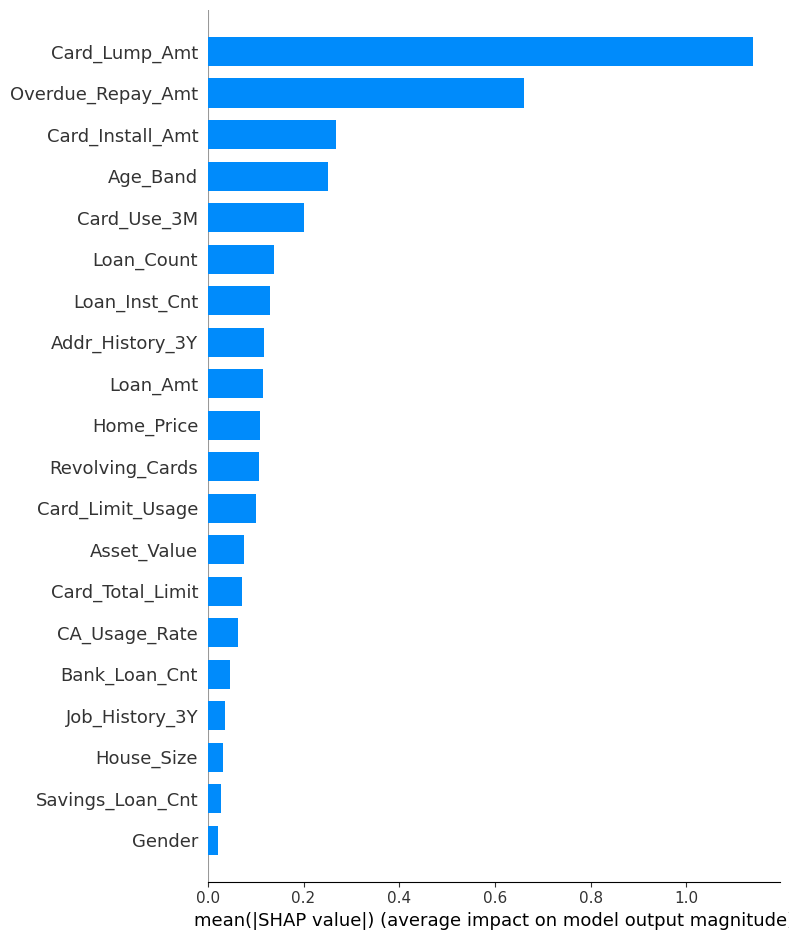

In [ ]:
shap.summary_plot(shap_values, X_test_tree, plot_type='bar')

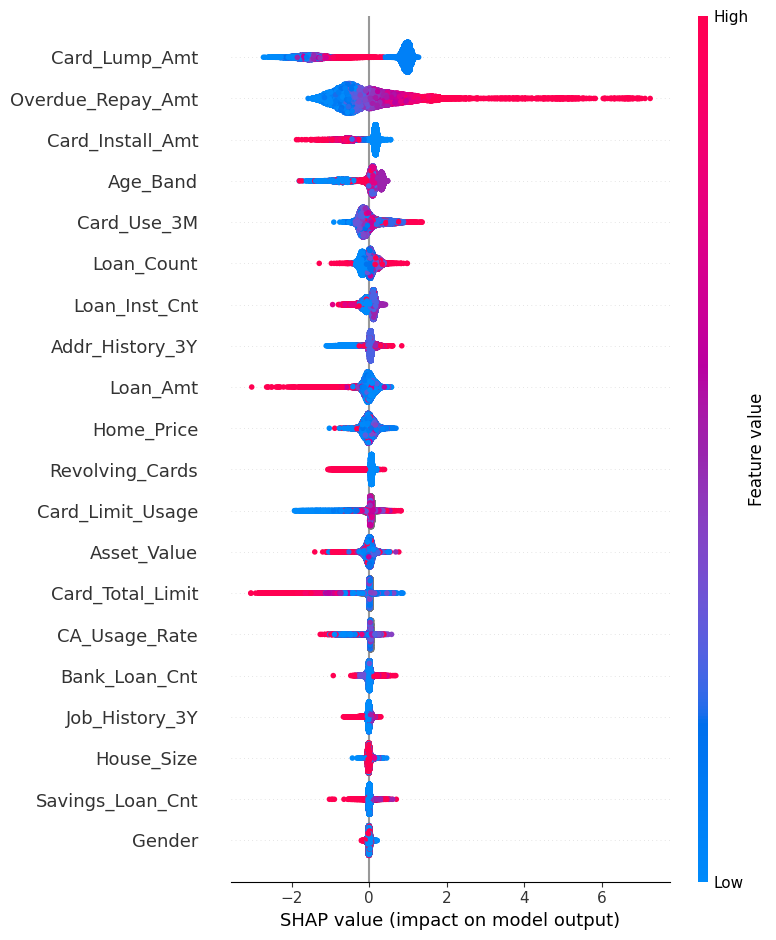

In [ ]:
shap.summary_plot(shap_values, X_test_tree)

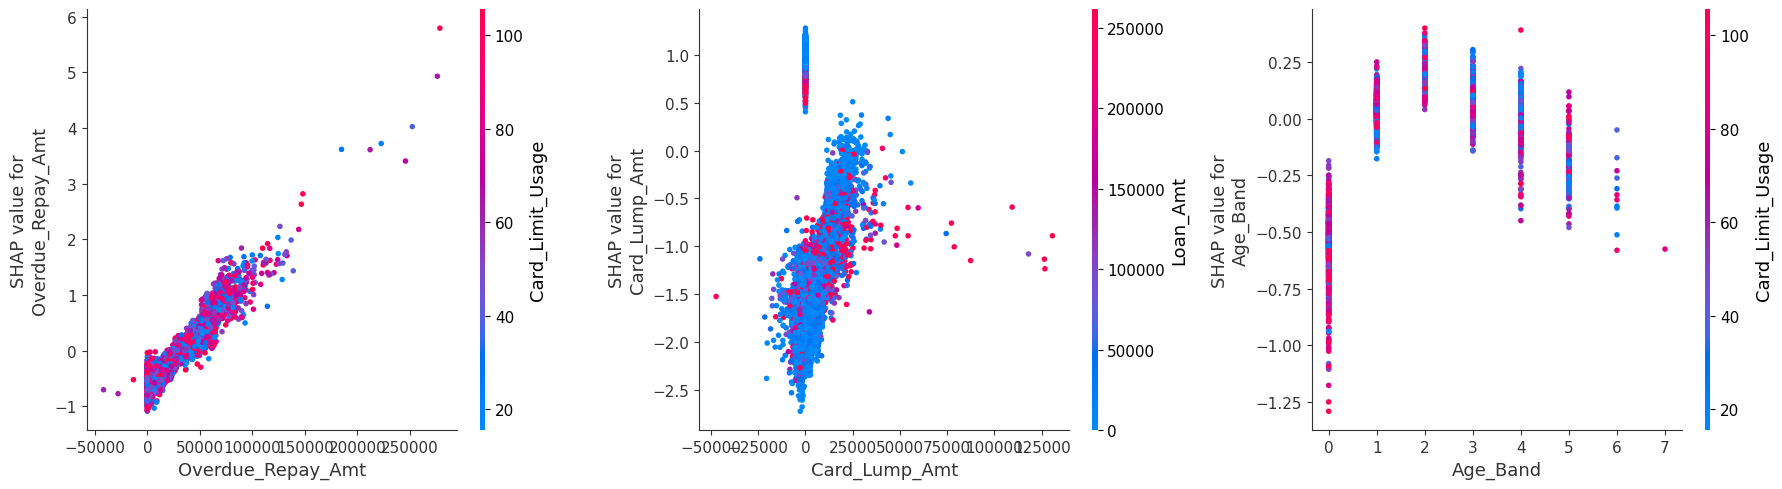

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(['Overdue_Repay_Amt', 'Card_Lump_Amt', 'Age_Band']):
    shap.dependence_plot(feat, shap_values, X_test_tree, ax=axes[i], show=False)

plt.tight_layout()
plt.show()

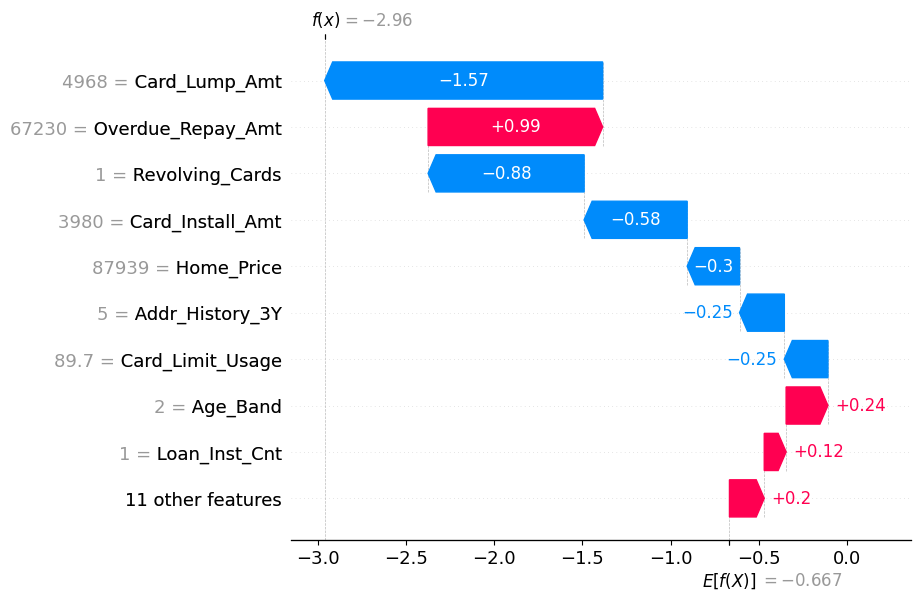

In [ ]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_tree.iloc[0],
    feature_names=X_test_tree.columns.tolist()
))

모델 성능 평가, 검증 부분


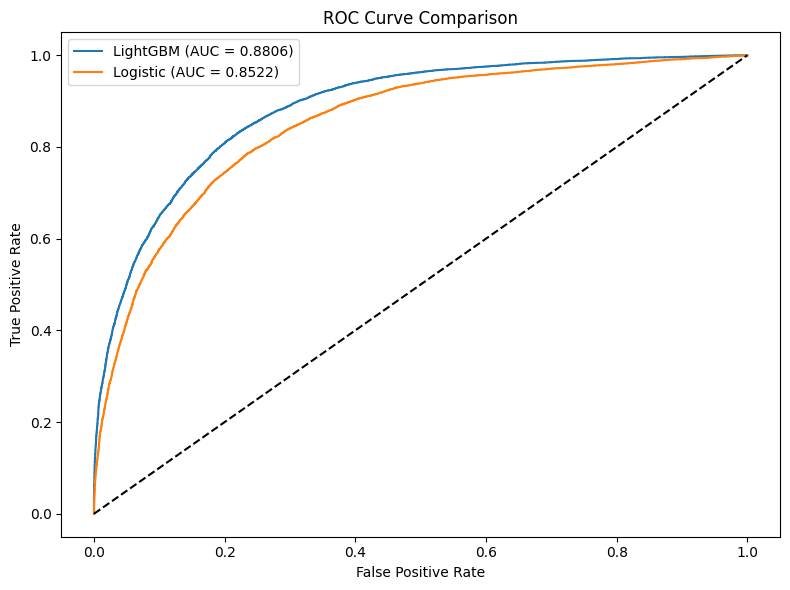

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_tuned2)
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit_tuned2)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = 0.8806)')
plt.plot(fpr_logit, tpr_logit, label=f'Logistic (AUC = 0.8522)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

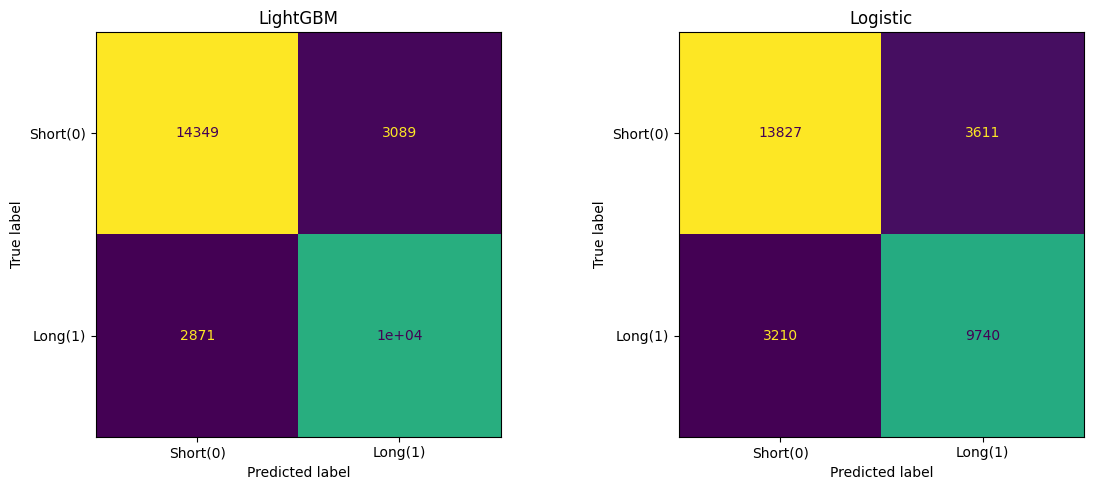

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_tuned2, y_pred_logit_tuned2],
                              ['LightGBM', 'Logistic']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Short(0)', 'Long(1)'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

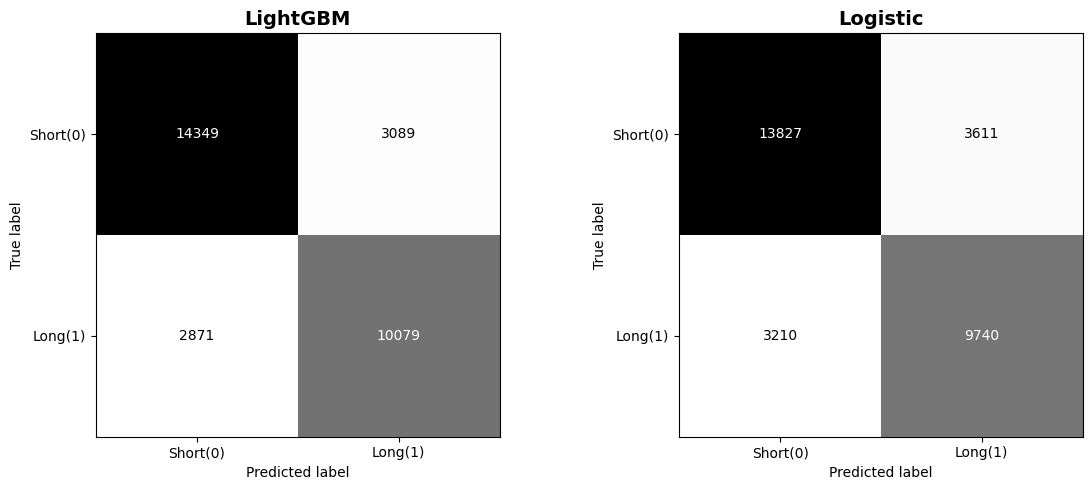

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 색상을 'Blues'로 설정하여 더 깔끔하고 전문적인 느낌을 줍니다.
# values_format='d'를 통해 숫자를 정수로 깔끔하게 표시합니다.
for ax, y_pred, title in zip(axes,
                              [y_pred_tuned2, y_pred_logit_tuned2],
                              ['LightGBM', 'Logistic']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Short(0)', 'Long(1)'])

    # cmap='Blues' 또는 cmap='Greys' 추천
    disp.plot(ax=ax, cmap='Greys', values_format='d', colorbar=False)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(False) # 그리드 제거로 더 깔끔하게

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
import pandas as pd

# 단기회복군(0) / 장기고착군(1) 인덱스 분리
idx_0 = y_test[y_test == 0].index
idx_1 = y_test[y_test == 1].index

X_test_reset = X_test_tree.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

idx_0 = y_test_reset[y_test_reset == 0].index
idx_1 = y_test_reset[y_test_reset == 1].index

results = []
for i, col in enumerate(X_test_tree.columns):
    shap_0 = shap_values[idx_0, i]
    shap_1 = shap_values[idx_1, i]
    t_stat, p_val = stats.ttest_ind(shap_0, shap_1)
    results.append({'Feature': col, 't-statistic': round(t_stat, 4), 'p-value': round(p_val, 4)})

df_ttest = pd.DataFrame(results).sort_values('p-value')
print(df_ttest)

              Feature  t-statistic  p-value
0              Gender      -8.6857    0.000
1            Age_Band     -38.1897    0.000
2       Card_Lump_Amt    -111.3812    0.000
3    Card_Install_Amt     -88.1875    0.000
4    Card_Limit_Usage     -32.7429    0.000
5       CA_Usage_Rate     -35.4361    0.000
6     Revolving_Cards     -46.1224    0.000
7          Loan_Count     -16.0143    0.000
8            Loan_Amt     -26.6400    0.000
9    Savings_Loan_Cnt     -13.9756    0.000
10      Bank_Loan_Cnt     -10.0829    0.000
11  Overdue_Repay_Amt     -67.8527    0.000
12        Asset_Value     -16.0576    0.000
14     Job_History_3Y     -13.9693    0.000
15    Addr_History_3Y     -10.6486    0.000
16   Card_Total_Limit     -19.5367    0.000
18         Home_Price     -10.3000    0.000
17      Loan_Inst_Cnt     -32.2993    0.000
19        Card_Use_3M     -38.1607    0.000
13         House_Size      -2.5109    0.012


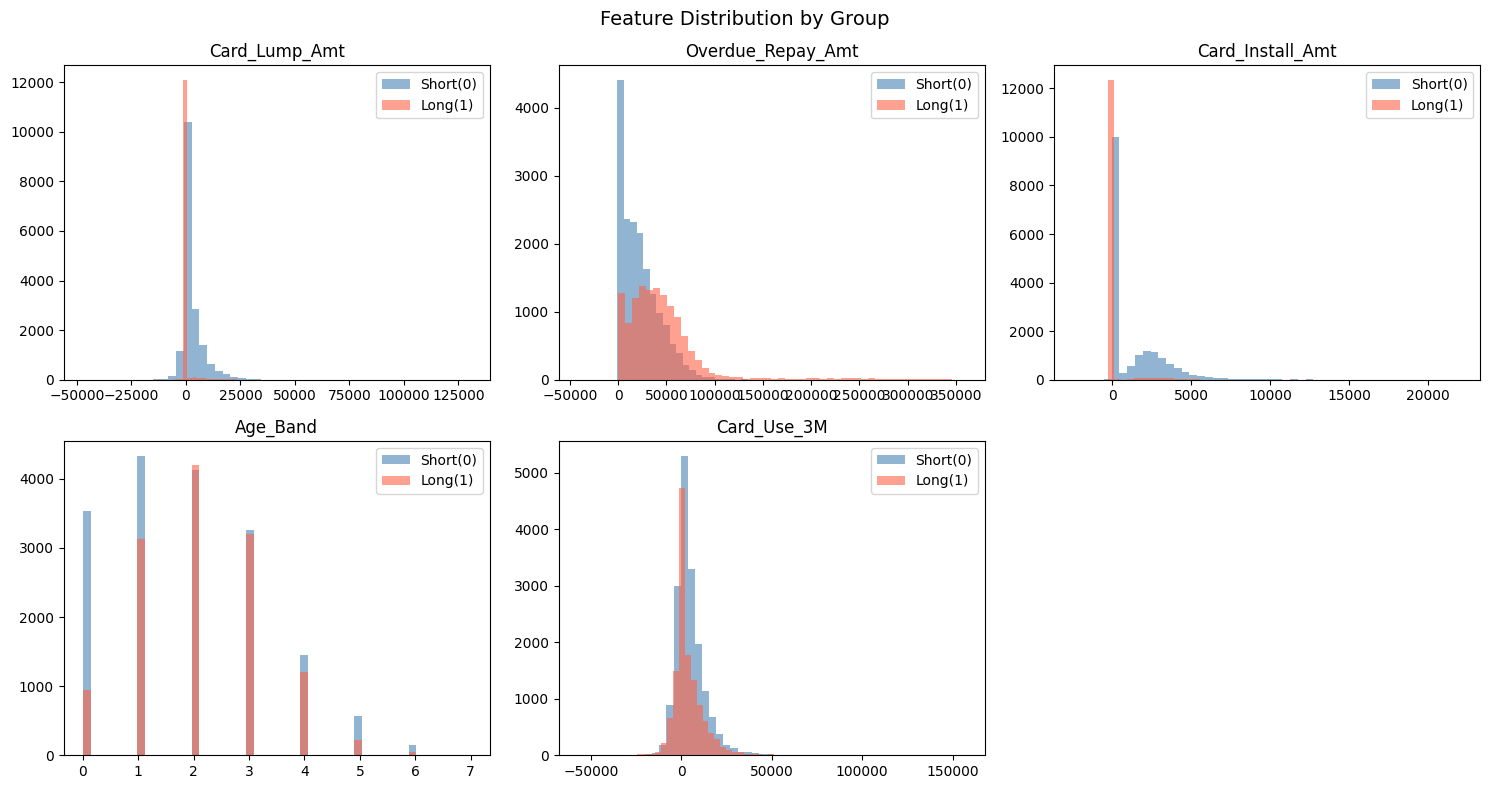

In [ ]:
top5 = ['Card_Lump_Amt', 'Overdue_Repay_Amt', 'Card_Install_Amt', 'Age_Band', 'Card_Use_3M']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top5):
    ax = axes[i]
    ax.hist(X_test_reset.loc[idx_0, col], bins=50, alpha=0.6, label='Short(0)', color='steelblue')
    ax.hist(X_test_reset.loc[idx_1, col], bins=50, alpha=0.6, label='Long(1)', color='tomato')
    ax.set_title(col)
    ax.legend()

axes[-1].set_visible(False)
plt.suptitle('Feature Distribution by Group', fontsize=14)
plt.tight_layout()
plt.show()